<a href="https://colab.research.google.com/github/jschmidt241/enso_dl_prediction/blob/main/enso_dl_with_roni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install xarray

In [ ]:
### Cleaning up data pulled from NOAA at: https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/roni/
roni_raw = pd.read_csv('/content/drive/MyDrive/colab_data/roni/RONI_6_2026.csv')
roni_long = pd.melt(
    roni_raw,
    id_vars=['Year'],
    value_vars=['01','02','03','04','05','06','07','08','09','10','11','12'],
    var_name='Month',
    value_name='roni_index'
)
roni_long['date'] = roni_long['Year'].astype(str) + roni_long['Month']
roni = roni_long.drop(['Year','Month'],axis=1).dropna()

In [ ]:
roni.reset_index().to_csv('/content/drive/MyDrive/colab_data/roni_index.csv',index=False)

## Download sea-surface temperature datasets from NOAA (~5-min runtime)
TODO: check whether combined_sst exists or check its temporal extent before downloading.

In [ ]:
download_dir = '/content/drive/MyDrive/colab_data'
os.makedirs(download_dir, exist_ok=True)

URL_TEMPLATE = 'https://www.ncei.noaa.gov/data/sea-surface-temperature-extended-reconstructed/v6/access/ersst.v6.{date}.nc'

print("downloading monthly ssta files")
for date in roni['date']:
    url = URL_TEMPLATE.format(date=date)
    file_path = os.path.join(download_dir, f'ersst.v6.{date}.nc')

    # download only if it doesn't already exist
    if not os.path.exists(file_path):
        response = requests.get(url)
        if response.status_code == 200:
            with open(file_path, 'wb') as f:
                f.write(response.content)
        else:
            print(f"Failed to download {url}")
print("done downloading\n")

# use xarray to combine the separate nc files, then save for future
combined_ds = xr.open_mfdataset(os.path.join(download_dir, 'ersst.v6.*.nc'), combine='by_coords')
combined_nc_path = '/content/drive/MyDrive/colab_data/combined_sst.nc'
combined_ds.to_netcdf(combined_nc_path)
print(f"saved combined dataset to {combined_nc_path}")

downloading monthly ssta files
done downloading

saved combined dataset to /content/drive/MyDrive/colab_data/combined_sst.nc


## Skip to here if data is downloaded already

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import xarray as xr
import numpy as np
import os
import requests
import random
import itertools

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, Dense, LSTM, Bidirectional

In [3]:
combined_ds = xr.open_dataset('/content/drive/MyDrive/colab_data/combined_sst.nc')
# which to slice depends on the temporal coverages of both index and sst data!
combined_ds = combined_ds.isel(time=slice(0,-1))
roni = pd.read_csv('/content/drive/MyDrive/colab_data/roni_index.csv').drop(['index'],axis=1)
roni.set_index('date',inplace=True)
roni.sort_index(inplace=True)

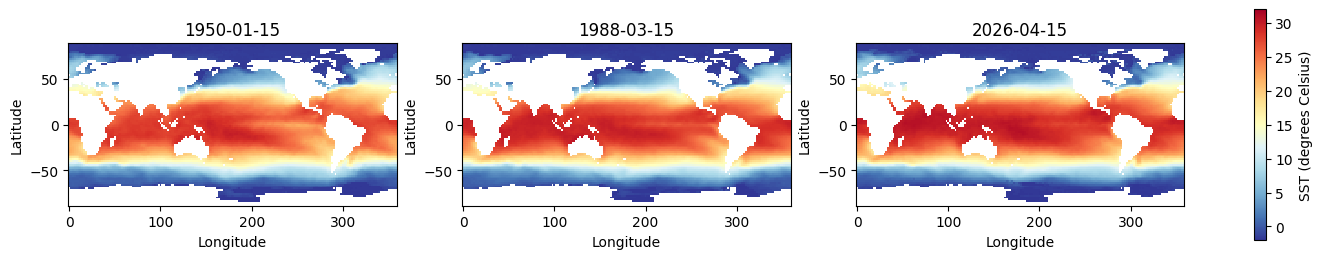

In [4]:
# Select a few time points and see what we're working with
times = [0, len(combined_ds.time)//2, -1]  # first, middle, last

fig, axes = plt.subplots(1, 3, figsize=(18, 3))

for ax, t in zip(axes, times):
    sst = combined_ds.sst.isel(time=t,lev=0)
    im = ax.pcolormesh(combined_ds.lon, combined_ds.lat, sst, cmap='RdYlBu_r', vmin=-2, vmax=32)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(str(combined_ds.time[t].values)[:10])
    ax.set_aspect('equal')

plt.colorbar(im, ax=axes, label='SST (degrees Celsius)', orientation='vertical', pad=0.05)
plt.show()

S_LN - Strong La Nina (RONI ≤ -1.5 °C)

M_LN - Moderate La Nina (-1.5 °C < RONI ≤ -1 °C)

NN_LN - Near Neutral La Nina (-1 °C < RONI ≤ -0.5 °C)

Neutral - Neutral ( -0.5 °C < RONI < +0.5 °C )

NN_EN - Near Neutral El Nino (+0.5 °C ≤ RONI < +1 °C)

M_EN - Moderate El Nino (+1 °C ≤ RONI < +1.5 °C)

S_EN - Strong El Nino (+1.5 °C ≤ RONI)

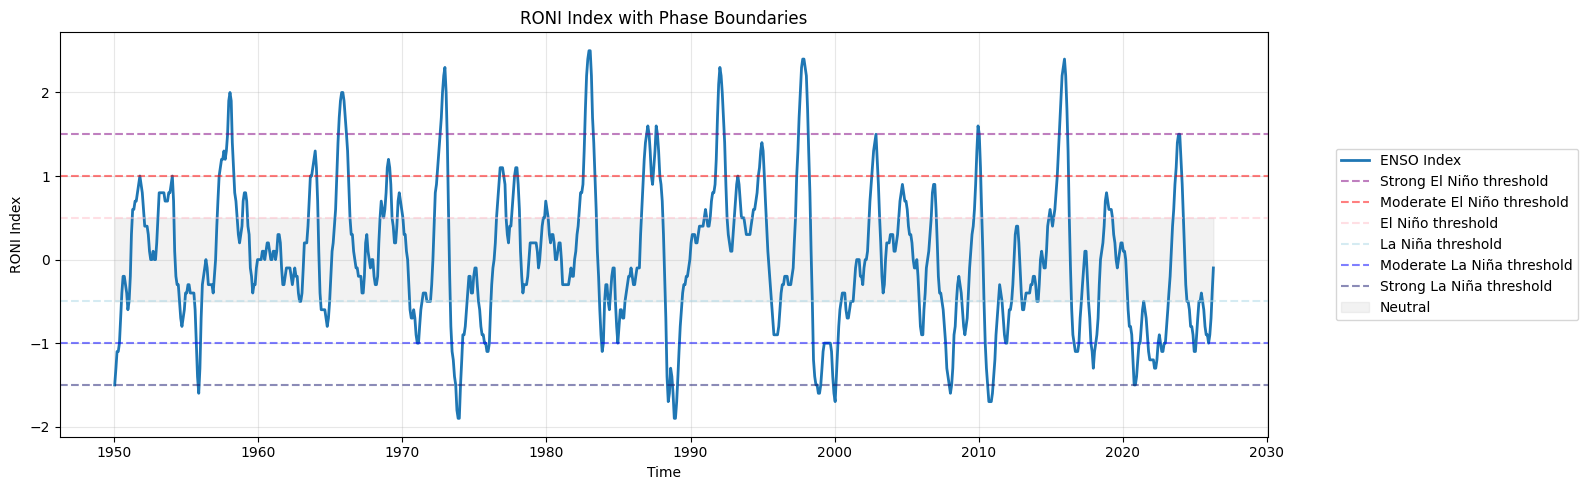

In [5]:
# enso index over time, include classifications of phase
fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

ax1.plot(combined_ds.time.values, roni.values.flatten(), linewidth=2, label='ENSO Index')
ax1.axhline(y=1.5, color='purple', linestyle='--', alpha=0.5, label='Strong El Niño threshold')
ax1.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Moderate El Niño threshold')
ax1.axhline(y=0.5, color='pink', linestyle='--', alpha=0.5, label='El Niño threshold')
ax1.axhline(y=-0.5, color='lightblue', linestyle='--', alpha=0.5, label='La Niña threshold')
ax1.axhline(y=-1.0, color='b', linestyle='--', alpha=0.5, label='Moderate La Niña threshold')
ax1.axhline(y=-1.5, color='midnightblue', linestyle='--', alpha=0.5, label='Strong La Niña threshold')
ax1.fill_between(combined_ds.time.values, -0.5, 0.5, alpha=0.2, color='silver', label='Neutral')
ax1.set_xlabel('Time')
ax1.set_ylabel('RONI Index')
ax1.set_title('RONI Index with Phase Boundaries')
ax1.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.tight_layout()
plt.show()

### Helper functions

These functions help split up the input data for the kind of model we want to train.

In [21]:
def classify_enso(values):
    classified = np.where(values < -0.5, 0,
                 np.where(values > 0.5, 2,
                          1))
    return classified

def classify_enso_with_strength(values):
  classified = np.where(values < -1.5, 0,
               np.where(values < -1.0, 1,
               np.where(values < -0.5, 2,
               np.where(values <  0.5, 3,
               np.where(values <  1.0, 4,
               np.where(values <  1.5, 5,6))))))
  return classified

def create_sequences_with_lead(data, targets, seq_length, lead_time=1):
  X, y = [], []
  # lead_time=1 is the very next month. lead_time=3 is 3 months ahead.
  for i in range(len(data) - seq_length - lead_time + 1):
    X.append(data[i : i+seq_length])
    y.append(targets[i + seq_length + lead_time - 1])
  return np.array(X), np.array(y)

def build_model_with_config(seq_length, cnn_filters, lstm, bidirectional, learning_rate, dropout, lat_size, lon_size):
  # Build the model dynamically
  model = Sequential([
      layers.Input(shape=(seq_length, lat_size, lon_size, 1)),
      TimeDistributed(layers.Conv2D(cnn_filters, 3, padding='same', activation='relu')),
      TimeDistributed(layers.BatchNormalization()),
      TimeDistributed(layers.MaxPooling2D(pool_size=(2, 2))),
      TimeDistributed(layers.Flatten())
  ])

  # Add LSTM (Bidirectional or Standard)
  if bidirectional:
      model.add(layers.Bidirectional(LSTM(lstm)))
  else:
      model.add(LSTM(lstm))

  model.add(layers.Dropout(dropout))
  model.add(layers.Dense(32, activation='relu'))
  model.add(layers.Dropout(dropout))
  model.add(layers.Dense(1)) # Linear activation for regression

  model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
  return model

class_names = ['La Nina (<-0.5)', 'Neutral', 'El Nino (>0.5)']
class_names_with_strength = ['Strong La Nina (<-1.5)','Moderate La Nina (<-1.0)','La Nina (<-0.5)','Neutral (<0.5)','El Nino (<1.0)','Moderate El Nino (<1.5)','Strong El Nino']

In [7]:
# Filter to the ENSO Standard Domain (120°E to 90°W, 20°S to 20°N):
lon_mask = (combined_ds.lon >= 120) & (combined_ds.lon <= 270)
lat_mask = (combined_ds.lat >= -20) & (combined_ds.lat <= 20)

ssta_enso = combined_ds['ssta'].sel(lon=lon_mask, lat=lat_mask).values
ssta_enso = np.squeeze(ssta_enso, axis=1)

print(f"ENSO region shape: {ssta_enso.shape}")

# Replace NaNs (land masses) with 0.0 before normalizing
ssta_enso = np.nan_to_num(ssta_enso, nan=0.0)

ssta_normalized = (ssta_enso - np.mean(ssta_enso)) / np.std(ssta_enso)
ssta_normalized = np.expand_dims(ssta_normalized, axis=-1)

enso_intensities = roni['roni_index'].values
dataset = tf.data.Dataset.from_tensor_slices((ssta_normalized, enso_intensities))

lat_size, lon_size = ssta_normalized.shape[1:3]

ENSO region shape: (916, 21, 76)


## Model Configuration

In [8]:
# Define a hyperparameter space
hyperparams_reg_expanded = {
    'seq_length': [3, 6, 9, 12],
    'cnn_filters': [32, 64],
    'lstm': [32, 64],
    'bidirectional': [True, False],
    'learning_rate': [0.001, 0.0005],
    'dropout': [0.2, 0.3, 0.4]
}
number_of_samples = 50   #
lead = 1                 # number of months ahead the model tries to predict
verbose = 0              # 0: not verbose, 1: verbose (NOT RECOMMENDED FOR BIG HYPERPARAMETER SEARCH SPACE)
patience = 15
batch_size = 16

# Generate all possible combinations
keys = list(hyperparams_reg_expanded.keys())
values = list(hyperparams_reg_expanded.values())
all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
number_of_samples = len(all_combinations) if number_of_samples > len(all_combinations) else number_of_samples

# Randomly sample some number of combinations to keep runtime reasonable
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

sampled_combinations = random.sample(all_combinations, number_of_samples)
print(f"Hyperparameter tuning will test {len(sampled_combinations)} random samples of {len(all_combinations)} possible combinations")


Hyperparameter tuning will test 50 random samples of 192 possible combinations


In [9]:
results_reg_expanded = []
for i, config in enumerate(sampled_combinations):
  early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=patience,
    restore_best_weights=True,
    verbose=verbose
  )
  model = build_model_with_config(**config, lat_size=lat_size, lon_size=lon_size)

  # Create sequences
  X_seq_lead, y_seq_lead = create_sequences_with_lead(ssta_normalized, enso_intensities, config['seq_length'], lead)

  # Split up traing, validation, and test sequences
  n = len(X_seq_lead)
  train_end, val_end = int(0.7 * n), int(0.85 * n)
  X_train_r, y_train_r = X_seq_lead[:train_end], y_seq_lead[:train_end]
  X_val_r, y_val_r = X_seq_lead[train_end:val_end], y_seq_lead[train_end:val_end]
  X_test_r, y_test_r = X_seq_lead[val_end:], y_seq_lead[val_end:]

  model.fit(X_train_r, y_train_r, validation_data=(X_val_r, y_val_r),
            epochs=100, batch_size=batch_size, verbose=verbose, callbacks=[early_stopping])

  # Evaluate model
  pred_r = model.predict(X_test_r, verbose=verbose)
  r2 = r2_score(y_test_r, pred_r)
  mae = mean_absolute_error(y_test_r, pred_r)

  config_copy = config.copy()
  config_copy['r2'] = r2
  config_copy['mae'] = mae
  results_reg_expanded.append(config_copy)

  print(f"[{i+1}/{number_of_samples}] -> R²: {r2:.4f}")
  print(config)
  print("=========================================")

results_reg_expanded_df = pd.DataFrame(results_reg_expanded).sort_values('r2', ascending=False)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 0.4565 - mae: 0.5270 - val_loss: 0.1472 - val_mae: 0.2997
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2675 - mae: 0.4044 - val_loss: 0.1415 - val_mae: 0.3008
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2586 - mae: 0.3812 - val_loss: 0.1496 - val_mae: 0.3111
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2366 - mae: 0.3692 - val_loss: 0.1701 - val_mae: 0.3334
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.2382 - mae: 0.3671 - val_loss: 0.1370 - val_mae: 0.2931
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.2365 - mae: 0.3632 - val_loss: 0.1341 - val_mae: 0.2762
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2061 - mae: 0.3472 - val_loss: 0.1347 - val_mae: 0.2845
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1921 - mae: 0.3347 - val_loss: 0.1247 - val_mae: 0.2748
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - l

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[3/50] -> R²: 0.7960
{'seq_length': 3, 'cnn_filters': 32, 'lstm': 32, 'bidirectional': False, 'learning_rate': 0.001, 'dropout': 0.2}
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.4902 - mae: 0.5525 - val_loss: 0.1781 - val_mae: 0.3267
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3148 - mae: 0.4270 - val_loss: 0.1337 - val_mae: 0.2913
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2800 - mae: 0.3941 - val_loss: 0.1362 - val_mae: 0.2857
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2422 - mae: 0.3621 - val_loss: 0.1539 - val_mae: 0.3233
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2098 - mae: 0.3438 - val_loss: 0.1259 - val_mae: 0.2906
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2204 - mae: 0.3507 - val_loss: 0.1218 - val_mae: 0.2802
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1879 - mae: 0.3228 - val_loss: 0.1215 - val_mae: 0.2838
Ep

In [10]:
print("Top 5 Best Combinations")
results_reg_expanded_df.head(5)

Top 5 Best Combinations


,seq_length,cnn_filters,lstm,bidirectional,learning_rate,dropout,r2,mae
10,3,32,64,False,0.0005,0.3,0.859196,0.259557
35,3,64,64,True,0.0005,0.2,0.857079,0.267055
14,3,32,32,False,0.0010,0.3,0.845342,0.286873
26,6,32,32,False,0.0010,0.4,0.844752,0.271706
19,12,32,32,False,0.0005,0.3,0.796937,0.310348


In [11]:
best_model = build_model_with_config(**results_reg_expanded_df.iloc[0].drop(['r2','mae']).to_dict(),lat_size=lat_size,lon_size=lon_size)

# make sequences using best model fit
X_seq_lead, y_seq_lead = create_sequences_with_lead(ssta_normalized, enso_intensities, int(results_reg_expanded_df.iloc[0]['seq_length']), lead)

# Split up traing, validation, and test sequences for best model sequences
n = len(X_seq_lead)
train_end, val_end = int(0.7 * n), int(0.85 * n)
X_train_r, y_train_r = X_seq_lead[:train_end], y_seq_lead[:train_end]
X_val_r, y_val_r = X_seq_lead[train_end:val_end], y_seq_lead[train_end:val_end]
X_test_r, y_test_r = X_seq_lead[val_end:], y_seq_lead[val_end:]

early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

history_lstm = best_model.fit(X_train_r, y_train_r, validation_data=(X_val_r, y_val_r),
          epochs=100, batch_size=batch_size, verbose=verbose, callbacks=[early_stopping])


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.4322 - mae: 0.4840 - val_loss: 0.1866 - val_mae: 0.3311
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2846 - mae: 0.3961 - val_loss: 0.1378 - val_mae: 0.2878
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2200 - mae: 0.3510 - val_loss: 0.1384 - val_mae: 0.2936
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2119 - mae: 0.3454 - val_loss: 0.1437 - val_mae: 0.2934
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1906 - mae: 0.3320 - val_loss: 0.0991 - val_mae: 0.2546
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1810 - mae: 0.3164 - val_loss: 0.1042 - val_mae: 0.2497
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1788 - mae: 0.3151 - val_loss: 0.1205 - val_mae: 0.2814
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1688 - mae: 0.3071 - val_loss: 0.1198 - val_mae: 0.2698
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step

CNN-LSTM R² Score: 0.7902


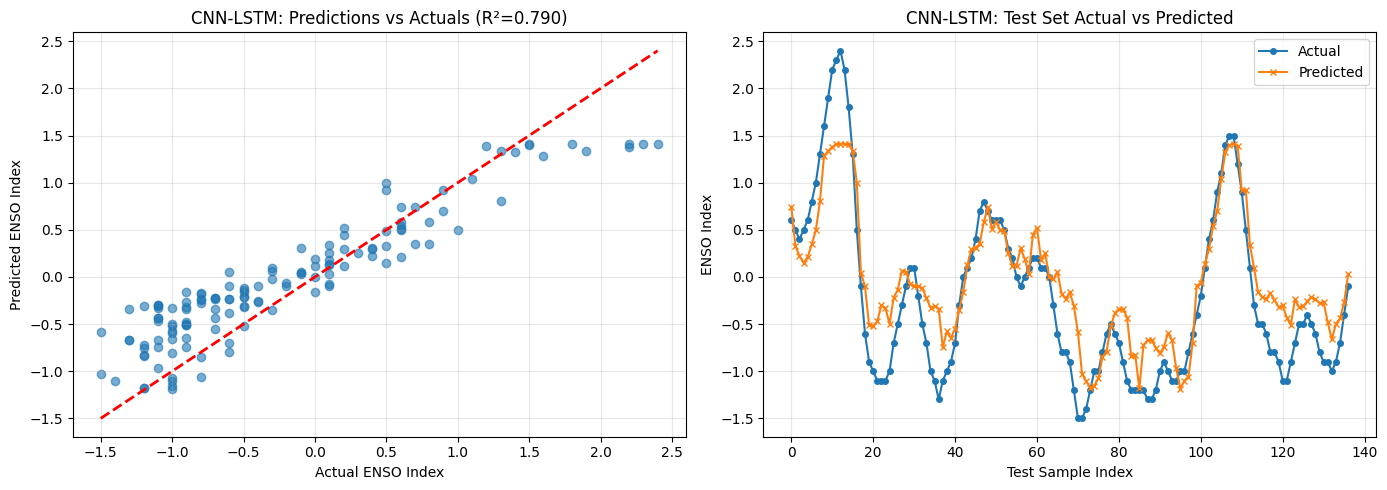

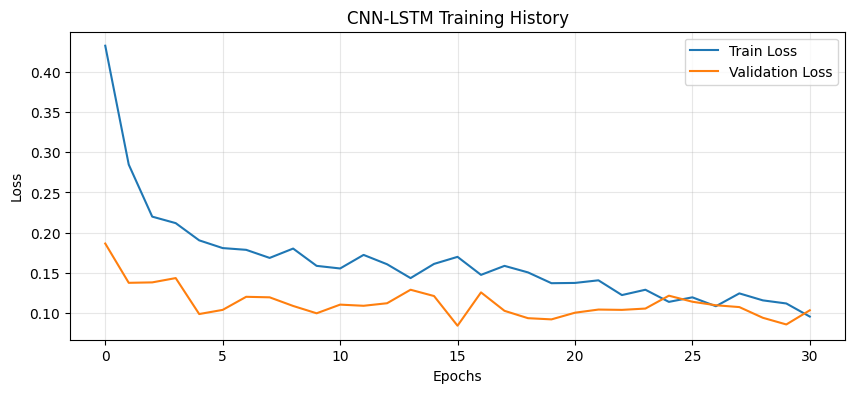

In [12]:
# Evaluate CNN-LSTM
test_predictions = best_model.predict(X_test_r)
test_actuals = y_test_r.reshape(-1, 1)

r2 = r2_score(test_actuals, test_predictions)
print(f"\nCNN-LSTM R² Score: {r2:.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(test_actuals, test_predictions, alpha=0.6)
plt.plot([test_actuals.min(), test_actuals.max()],
         [test_actuals.min(), test_actuals.max()],
         'r--', lw=2)
plt.xlabel('Actual ENSO Index')
plt.ylabel('Predicted ENSO Index')
plt.title(f'CNN-LSTM: Predictions vs Actuals (R²={r2:.3f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(test_actuals, label='Actual', marker='o', markersize=4)
plt.plot(test_predictions, label='Predicted', marker='x', markersize=4)
plt.xlabel('Test Sample Index')
plt.ylabel('ENSO Index')
plt.title('CNN-LSTM: Test Set Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Training history
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN-LSTM Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Classification evaluation for CNN-LSTM
test_actuals_class = classify_enso(test_actuals.flatten())
test_actuals_class_strength = classify_enso_with_strength(test_actuals.flatten())
test_predictions_class = classify_enso(test_predictions.flatten())
test_predictions_class_strength = classify_enso_with_strength(test_predictions.flatten())

accuracy = accuracy_score(test_actuals_class, test_predictions_class)
print(f"\nCNN-LSTM Classification Accuracy: {accuracy*100:.2f}%")

conf_matrix = confusion_matrix(test_actuals_class, test_predictions_class)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Count')
plt.xticks([0, 1, 2], class_names, rotation=45, ha='right')
plt.yticks([0, 1, 2], class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'CNN-LSTM Classification Confusion Matrix\nAccuracy: {accuracy:.2%}')

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(conf_matrix[i, j]),
                ha='center', va='center',
                color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black',
                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


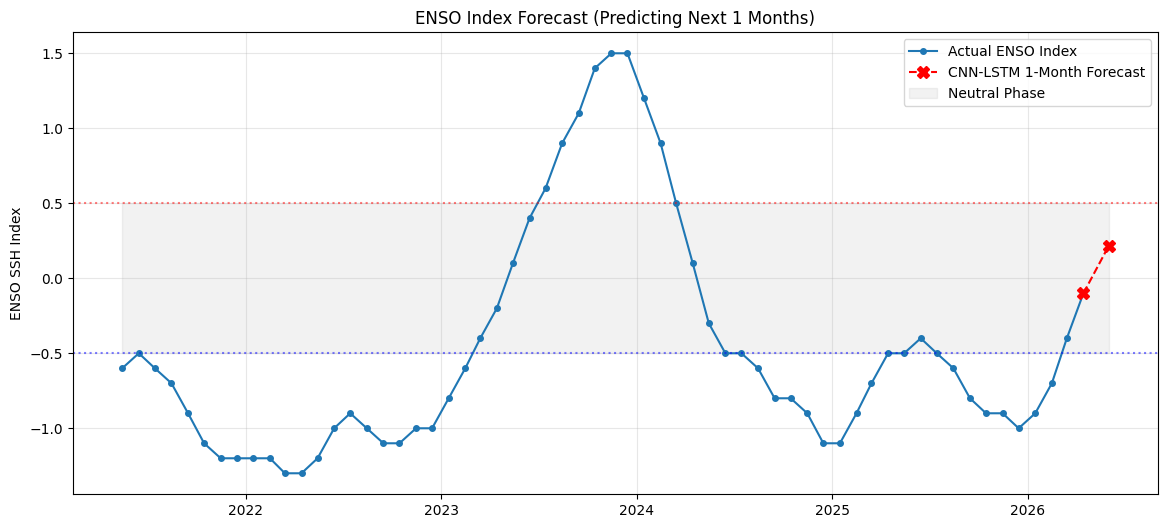


--- Forecasted Values ---
2026-06: 0.214 (Neutral)


In [14]:
# Generate the dates for the next 'lead' months (June, July, August 2026)
last_date = pd.to_datetime(combined_ds.time.values[-1])
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=lead, freq='MS')

# Extract the exact sequences needed to predict these future months.
# To predict T+1, T+2, T+3 using a lead=3 model, we feed it data ending at T-2, T-1, and T.
X_future = []
n_total = len(ssta_normalized)
for i in range(lead, 0, -1):
    end_idx = n_total - i + 1
    start_idx = end_idx - results_reg_expanded_df.iloc[0]['seq_length']
    X_future.append(ssta_normalized[start_idx:end_idx])
X_future = np.array(X_future)

# Make the predictions
future_preds = best_model.predict(X_future).flatten()

# --- Visualization ---
plt.figure(figsize=(14, 6))

# Plot last 5 years of known data for context (60 months)
plot_start_idx = -60
past_dates = pd.to_datetime(combined_ds.time.values[plot_start_idx:])
past_actuals = roni['roni_index'].values[plot_start_idx:]

plt.plot(past_dates, past_actuals, label='Actual ENSO Index', marker='o', markersize=4, linestyle='-')

# Connect the last known point to the first prediction for visual continuity
concat_dates = [past_dates[-1]] + list(future_dates)
concat_values = [past_actuals[-1]] + list(future_preds)

plt.plot(concat_dates, concat_values, label=f'CNN-LSTM {lead}-Month Forecast', marker='X', markersize=8, linestyle='--', color='red')

# Add Phase thresholds
plt.axhline(y=0.5, color='r', linestyle=':', alpha=0.5)
plt.axhline(y=-0.5, color='b', linestyle=':', alpha=0.5)

# Fill background for the neutral zone
all_dates_plotted = list(past_dates) + list(future_dates)
plt.fill_between(all_dates_plotted, -0.5, 0.5, color='gray', alpha=0.1, label='Neutral Phase')

plt.title(f'ENSO Index Forecast (Predicting Next {lead} Months)')
plt.ylabel('ENSO SSH Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the raw forecast values
print("\n--- Forecasted Values ---")
for d, p in zip(future_dates, future_preds):
    phase = "El Niño" if p > 0.5 else "La Niña" if p < -0.5 else "Neutral"
    print(f"{d.strftime('%Y-%m')}: {p:.3f} ({phase})")